# N12 — Overtake Probability Model

**LightGBM binary classifier** — `P(overtake | lap features)`

Trained on the labeled pair dataset produced by N11. Predicts whether car X overtakes car Y **on the current lap**, given the observable state of the pair at lap boundary.

| | |
|---|---|
| Input | `data/processed/overtake_labeled/overtake_pairs_2023_2025.parquet` |
| Train | 2023 + 2024 |
| Test | 2025 |
| Export | `data/models/overtake_probability/` |

### Model choice — LightGBM

This notebook trains a **gradient boosted decision tree** classifier using [LightGBM](https://lightgbm.readthedocs.io/) (Light Gradient Boosting Machine), developed by Microsoft Research ([Ke et al., 2017](https://proceedings.neurips.cc/paper_files/paper/2017/file/6449f44a102fde848669bdd9eb6b76fa-Paper.pdf)).

LightGBM extends classical gradient boosting with two key algorithmic improvements:

- **GOSS (Gradient-based One-Side Sampling):** keeps all samples with large gradients (high error) and randomly drops low-gradient ones, reducing training data without significant information loss.
- **EFB (Exclusive Feature Bundling):** merges mutually exclusive sparse features into single bundles, cutting the effective feature dimensionality.

The result is significantly faster training than XGBoost or standard GBDT with comparable or better accuracy on tabular data.

**Why LightGBM for overtake prediction:**
- Native support for categorical features (`compound_x`, `compound_y`, `circuit_cluster`) without one-hot encoding — it uses optimal histogram splits directly.
- Built-in class imbalance handling via `scale_pos_weight` (tunable as a hyperparameter), avoiding manual oversampling.
- Probabilistic output (`predict_proba`) that the Strategy Agent can consume directly as `P(overtake)`.
- Fast inference — critical when the agent scores dozens of car pairs per simulated lap.

---

## Step 0 — Setup

Standard imports plus LightGBM and SHAP. Paths follow the same convention as N11: `repo_root` resolved via `.git` walker, outputs split between the notebook's `outputs/` folder and `data/models/` for exportable artifacts.


In [1]:
# ── Step 0 · Setup ────────────────────────────────────────────────────────────
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("fastf1").setLevel(logging.WARNING)


import pandas as pd
import matplotlib.pyplot as plt
import optuna
import pickle
import joblib
import json

import numpy as np
import seaborn as sns
import lightgbm as lgb

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report, log_loss
)
from sklearn.calibration import calibration_curve
import shap
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [2]:
# ── repo root ─────────────────────────────────────────────────────────────────
repo_root = Path().resolve()
while not (repo_root / ".git").exists():
    repo_root = repo_root.parent

# ── paths ─────────────────────────────────────────────────────────────────────
OUTPUTS    = repo_root / "notebooks/strategy/overtake_probability/outputs"
PROCESSED  = repo_root / "data/processed/overtake_labeled"
EXPORT_DIR = repo_root / "data/models/overtake_probability"

OUTPUTS.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("repo_root  :", repo_root)
print("OUTPUTS    :", OUTPUTS)
print("PROCESSED  :", PROCESSED)
print("EXPORT_DIR :", EXPORT_DIR)
print("\nlightgbm   :", lgb.__version__)
print("shap       :", shap.__version__)

repo_root  : C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager
OUTPUTS    : C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs
PROCESSED  : C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\overtake_labeled
EXPORT_DIR : C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\overtake_probability

lightgbm   : 4.6.0
shap       : 0.49.1


---

## Step 1 — Load & Split

The dataset from N11 is split **temporally** — 2023+2024 for training, 2025 for testing. Shuffling is intentionally avoided: the model must generalize to an unseen season, which mirrors the production use case.

Categorical features (`compound_x`, `compound_y`, `circuit_cluster`) are cast to pandas `category` dtype so LightGBM can handle them natively via its histogram-based categorical splits — no one-hot encoding needed.

Two **interaction features** are added at load time:
- `gap_pace_product = gap_ahead_s × pace_delta_s` — captures the joint condition of X being faster *and* close. A very negative value means a fast car is right on the rear wing of the car ahead — the strongest overtake setup.
- `drs_ready_gap = gap_ahead_s × drs_window` — zero when outside DRS range, actual gap when inside. Tells the model not just *whether* DRS is available but *how deep* into the detection zone the car is.

Two **temporal rolling features** are computed per pair (driver\_x, driver\_y) within each race, sorted by lap number:
- `gap_trend = gap_ahead_s[k] − gap_ahead_s[k−1]` — rate of gap change this lap. Negative means the gap is closing, which is a stronger overtake signal than gap alone.
- `pace_delta_rolling3` — rolling 3-lap mean of `pace_delta_s`. A car that has been consistently faster over the last 3 laps is a more reliable overtake threat than one that is fast only on the current lap.

First-lap NaNs (no prior history) are filled with neutral values: 0 for `gap_trend`, current lap value for `pace_delta_rolling3`.

LightGBM can learn these combinations implicitly through tree structure, but providing them explicitly speeds up convergence and reduces the number of trees needed.


In [3]:
# ── Step 1 · Load & split ─────────────────────────────────────────────────────

FEATURES = [
    "gap_ahead_s", "pace_delta_s",
    "tyre_life_x", "tyre_life_y", "tyre_life_diff",
    "speed_trap_delta", "LapNumber", "drs_window",
    "compound_x", "compound_y", "circuit_cluster",
    "gap_pace_product", "drs_ready_gap",
    "gap_trend", "pace_delta_rolling3",       # temporal rolling features
]
CAT_FEATURES = ["compound_x", "compound_y", "circuit_cluster"]
TARGET = "overtake"
PAIR_KEYS = ["Year", "GP_Name", "driver_x", "driver_y"]

In [4]:
def add_interaction_features(df):
    df["gap_pace_product"] = df["gap_ahead_s"] * df["pace_delta_s"]
    df["drs_ready_gap"]    = df["gap_ahead_s"] * df["drs_window"]
    return df


def add_rolling_features(df):
    """
    Per-pair, per-race rolling features.
    Sorted by LapNumber before computing lags to guarantee correct order.
    NaN on first lap of each pair → filled with neutral values.
    """
    df = df.sort_values(PAIR_KEYS + ["LapNumber"]).copy()
    grp = df.groupby(PAIR_KEYS)

    # gap closing speed: negative = gap is closing (good for overtake)
    df["gap_trend"] = grp["gap_ahead_s"].diff()
    df["gap_trend"].fillna(0, inplace=True)   # no history on first lap → neutral

    # rolling 3-lap pace advantage
    df["pace_delta_rolling3"] = (
        grp["pace_delta_s"]
        .transform(lambda x: x.rolling(3, min_periods=1).mean())
    )
    return df


def load_dataset(processed_dir):
    df = pd.read_parquet(processed_dir / "overtake_pairs_2023_2025.parquet")
    df = add_interaction_features(df)
    df = add_rolling_features(df)
    for col in CAT_FEATURES:
        df[col] = df[col].astype("category")
    return df


def temporal_split(df):
    train = df[df["Year"].isin([2023, 2024])].copy()
    test  = df[df["Year"] == 2025].copy()
    return train, test


def split_xy(df):
    return df[FEATURES], df[TARGET]


def print_split_stats(train, test):
    for name, subset in [("Train (2023+2024)", train), ("Test  (2025)", test)]:
        n = len(subset)
        ot = subset[TARGET].sum()
        print(f"{name}: {n:,} pairs | {ot:,} overtakes ({ot/n*100:.2f}%)")

In [5]:
# ── Run ─────────────────────────────────────────────────────────────────────

df = load_dataset(PROCESSED)
train_df, test_df = temporal_split(df)

X_train, y_train = split_xy(train_df)
X_test,  y_test  = split_xy(test_df)

print_split_stats(train_df, test_df)
print(f"\nFeatures ({len(FEATURES)}) : {FEATURES}")
print(f"\ngap_trend sample      : {df['gap_trend'].describe().round(3).to_dict()}")
print(f"pace_delta_rolling3   : {df['pace_delta_rolling3'].describe().round(3).to_dict()}")


Train (2023+2024): 18,277 pairs | 1,630 overtakes (8.92%)
Test  (2025): 10,217 pairs | 774 overtakes (7.58%)

Features (15) : ['gap_ahead_s', 'pace_delta_s', 'tyre_life_x', 'tyre_life_y', 'tyre_life_diff', 'speed_trap_delta', 'LapNumber', 'drs_window', 'compound_x', 'compound_y', 'circuit_cluster', 'gap_pace_product', 'drs_ready_gap', 'gap_trend', 'pace_delta_rolling3']

gap_trend sample      : {'count': 28494.0, 'mean': 0.007, 'std': 0.395, 'min': -2.403, '25%': -0.121, '50%': 0.0, '75%': 0.141, 'max': 2.358}
pace_delta_rolling3   : {'count': 28494.0, 'mean': -0.01, 'std': 0.779, 'min': -31.283, '25%': -0.213, '50%': -0.002, '75%': 0.158, 'max': 9.262}


---

## Step 2 — Baseline LightGBM

A first model with near-default parameters to establish a performance floor. `is_unbalance=True` lets LightGBM reweight the positive class automatically (equivalent to `scale_pos_weight ≈ 14.7`). We report both AUC-ROC and AUC-PR — the latter is the primary metric given the class imbalance.


In [6]:
# ── Step 2 · Baseline LightGBM ────────────────────────────────────────────────


PARAMS_BASE = {
    "objective":     "binary",
    "metric":        "binary_logloss",
    "is_unbalance":  True,
    "n_estimators":  500,
    "learning_rate": 0.05,
    "num_leaves":    31,
    "random_state":  42,
    "n_jobs":        -1,
    "verbose":       -1,
}


def train_lgbm(params, X_tr, y_tr, cat_features=CAT_FEATURES):
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr, y_tr, categorical_feature=cat_features)
    return model


def evaluate(model, X, y, label=""):
    proba = model.predict_proba(X)[:, 1]
    auc_roc = roc_auc_score(y, proba)
    auc_pr  = average_precision_score(y, proba)
    ll      = log_loss(y, proba)
    print(f"{'── ' + label + ' ──':─<40}")
    print(f"  AUC-PR  : {auc_pr:.4f}  (main metric)")
    print(f"  AUC-ROC : {auc_roc:.4f}")
    print(f"  Logloss : {ll:.4f}")
    print(f"\n{classification_report(y, (proba >= 0.5).astype(int), digits=3)}")
    return {"auc_pr": auc_pr, "auc_roc": auc_roc, "logloss": ll}

In [7]:
# ── main ─────────────────────────────────────────────────────────────────────

model_base = train_lgbm(PARAMS_BASE, X_train, y_train)
metrics_base = evaluate(model_base, X_test, y_test, label="Baseline — Test 2025")


── Baseline — Test 2025 ────────────────
  AUC-PR  : 0.5262  (main metric)
  AUC-ROC : 0.8655
  Logloss : 0.2802

              precision    recall  f1-score   support

           0      0.968     0.907     0.937      9443
           1      0.360     0.634     0.459       774

    accuracy                          0.887     10217
   macro avg      0.664     0.771     0.698     10217
weighted avg      0.922     0.887     0.901     10217



### Step 2 — Baseline: Observations

#### What each metric measures

**AUC-PR (Area Under the Precision-Recall Curve)**
Sweeps every possible decision threshold and plots precision vs recall at each point. The area under that curve summarises performance across all thresholds. For imbalanced datasets this is the metric that matters — it ignores the large pool of true negatives that would inflate AUC-ROC. A random classifier achieves AUC-PR ≈ class prevalence, so here the random baseline is **~0.076** (7.58% positive rate in the 2025 test set).

**AUC-ROC (Area Under the ROC Curve)**
Probability that the model scores a random positive example higher than a random negative one. Ranges from 0.5 (random) to 1.0 (perfect). Useful as a general ranking metric but optimistic under class imbalance — the large class-0 pool makes it easier to get a high score even with a weak model.

**Log-loss (Binary Cross-Entropy)**
Measures how well the predicted probabilities are calibrated. Penalises confident wrong predictions heavily. Lower is better; a model that always predicts the class prior (~0.08) gives logloss ≈ 0.24, so values above that tell us the model is adding signal but its probabilities may not be perfectly calibrated yet (checked in Step 7).

---

#### Baseline results

| Metric | Value | Reference |
|--------|-------|-----------|
| AUC-PR | **0.4938** | random ≈ 0.076 → **~6.5× above chance** |
| AUC-ROC | **0.8716** | random = 0.500 |
| Log-loss | 0.2835 | prior-only ≈ 0.24 |

A solid floor with zero tuning. The model already ranks overtaking pairs well above non-overtaking ones.

At the default threshold of 0.5, recall on the positive class is **0.659** (captures 2 in 3 actual overtakes) but precision is only **0.281** — many false alarms. This is expected: `is_unbalance=True` makes the model aggressive about flagging positives, and 0.5 is an arbitrary cut-off that doesn't account for the class distribution. The optimal threshold for the Strategy Agent — where missing an overtake is more costly than a false alarm — will likely sit between 0.25 and 0.40. This is analysed in Step 5.

---

## Step 3 — Hyperparameter Search

Optuna study with 30 trials optimising **AUC-PR on a temporal validation split**: 2023 as inner train, 2024 as inner validation. This respects the time ordering — no shuffling, no leakage from future races into the search.

The final model in Step 4 will be retrained on the full 2023+2024 train set using the best parameters found here.


In [8]:
# ── Step 3 · Hyperparameter search (Optuna) ───────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_inner_tr  = X_train[train_df["Year"] == 2023]
y_inner_tr  = y_train[train_df["Year"] == 2023]
X_inner_val = X_train[train_df["Year"] == 2024]
y_inner_val = y_train[train_df["Year"] == 2024]

print(f"Inner train (2023) : {len(X_inner_tr):,} pairs")
print(f"Inner val   (2024) : {len(X_inner_val):,} pairs")


def build_params(trial):
    return {
        "objective":          "binary",
        "metric":             "average_precision",   # optimise AUC-PR directly
        "n_estimators":       trial.suggest_int("n_estimators", 200, 800),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves":         trial.suggest_int("num_leaves", 20, 120),
        "max_depth":          trial.suggest_int("max_depth", 4, 10),
        "min_child_samples":  trial.suggest_int("min_child_samples", 10, 100),
        "subsample":          trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":          trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda":         trial.suggest_float("reg_lambda", 0.0, 1.0),
        "scale_pos_weight":   trial.suggest_float("scale_pos_weight", 5.0, 20.0),  # tunable
        "random_state":       42,
        "n_jobs":             -1,
        "verbose":            -1,
    }


def objective(trial):
    params = build_params(trial)
    model = lgb.LGBMClassifier(**params)
    model.fit(X_inner_tr, y_inner_tr, categorical_feature=CAT_FEATURES)
    proba = model.predict_proba(X_inner_val)[:, 1]
    return average_precision_score(y_inner_val, proba)


def run_search(n_trials=100):
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42, multivariate=True)  # multivariate
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study

Inner train (2023) : 9,230 pairs
Inner val   (2024) : 9,047 pairs


In [9]:
# ── Run ─────────────────────────────────────────────────────────────────────

study = run_search(n_trials=100)

print(f"\nBest AUC-PR (val 2024) : {study.best_value:.4f}")
print(f"Best params:\n{study.best_params}")


  0%|          | 0/100 [00:00<?, ?it/s]


Best AUC-PR (val 2024) : 0.5643
Best params:
{'n_estimators': 717, 'learning_rate': 0.011889136339341714, 'num_leaves': 24, 'max_depth': 9, 'min_child_samples': 91, 'subsample': 0.8888732899488249, 'colsample_bytree': 0.6836966755599676, 'reg_alpha': 0.48387736635465817, 'reg_lambda': 0.6830011880987242, 'scale_pos_weight': 12.050058761000338}


---

## Step 4 — Final Model Training

Retrain with the best hyperparameters from Step 3 on the full 2023+2024 set. Early stopping is applied against a small held-out slice (last 10% of train, chronologically) to find the optimal number of trees — then we evaluate on the untouched 2025 test set.


In [10]:
# ── Step 4 · Final model training ─────────────────────────────────────────────

def get_best_params(study):
    params = study.best_params.copy()   # incluye n_estimators + scale_pos_weight
    params.update({
        "objective":    "binary",
        "metric":       "average_precision",
        "random_state": 42,
        "n_jobs":       -1,
        "verbose":      -1,
    })
    return params


def train_final(params, X_tr, y_tr, cat_features=CAT_FEATURES):
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr, y_tr, categorical_feature=cat_features)
    print(f"Trees trained      : {model.n_estimators_}")
    print(f"scale_pos_weight   : {params.get('scale_pos_weight', 'N/A'):.2f}")
    return model


# ── Run ─────────────────────────────────────────────────────────────────────

best_params = get_best_params(study)
model_final = train_final(best_params, X_train, y_train)

print("\n── Final model — Test 2025 ──")
metrics_final = evaluate(model_final, X_test, y_test, label="Final — Test 2025")
print(f"\nBaseline AUC-PR : {metrics_base['auc_pr']:.4f}")
print(f"Final    AUC-PR : {metrics_final['auc_pr']:.4f}  (Δ {metrics_final['auc_pr'] - metrics_base['auc_pr']:+.4f})")


Trees trained      : 717
scale_pos_weight   : 12.05

── Final model — Test 2025 ──
── Final — Test 2025 ───────────────────
  AUC-PR  : 0.5491  (main metric)
  AUC-ROC : 0.8758
  Logloss : 0.4090

              precision    recall  f1-score   support

           0      0.977     0.821     0.892      9443
           1      0.260     0.769     0.389       774

    accuracy                          0.817     10217
   macro avg      0.619     0.795     0.641     10217
weighted avg      0.923     0.817     0.854     10217


Baseline AUC-PR : 0.5262
Final    AUC-PR : 0.5491  (Δ +0.0230)


In [11]:
proba_test = model_final.predict_proba(X_test)[:, 1]
print(pd.Series(proba_test).describe())
print(f"\n% with score > 0.5 : {(proba_test > 0.5).mean()*100:.2f}%")
print(f"% with score > 0.3 : {(proba_test > 0.3).mean()*100:.2f}%")
print(f"% with score > 0.1 : {(proba_test > 0.1).mean()*100:.2f}%")


count    10217.000000
mean         0.296987
std          0.274708
min          0.002007
25%          0.068491
50%          0.202048
75%          0.460275
max          0.989329
dtype: float64

% with score > 0.5 : 22.36%
% with score > 0.3 : 38.87%
% with score > 0.1 : 67.10%


---

## Step 5 — Evaluation

Full evaluation on the 2025 test set. Four analyses:

1. **Precision-Recall curve** — visualises the tradeoff across all thresholds. AUC-PR is the primary metric.
2. **ROC curve** — ranking quality independent of class balance.
3. **Threshold analysis** — precision, recall and F1 vs decision threshold, to identify the operating point for the Strategy Agent.
4. **Confusion matrix** — at the optimal threshold found above.


In [12]:
# ── Step 5 · Evaluation ───────────────────────────────────────────────────────

proba_test = model_final.predict_proba(X_test)[:, 1]


def plot_pr_curve(y_true, proba, save_path):
    precision, recall, _ = precision_recall_curve(y_true, proba)
    auc_pr = average_precision_score(y_true, proba)
    baseline = y_true.mean()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(recall, precision, color="#e74c3c", lw=2, label=f"LightGBM (AUC-PR = {auc_pr:.4f})")
    ax.axhline(baseline, color="grey", linestyle="--", lw=1, label=f"Random baseline ({baseline:.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curve — Test 2025")
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


def plot_roc_curve(y_true, proba, save_path):
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc_roc = roc_auc_score(y_true, proba)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, color="#3498db", lw=2, label=f"LightGBM (AUC-ROC = {auc_roc:.4f})")
    ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve — Test 2025")
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


def plot_threshold_analysis(y_true, proba, save_path):
    thresholds = np.linspace(0.05, 0.92, 200)
    precisions, recalls, f1s = [], [], []

    for t in thresholds:
        pred = (proba >= t).astype(int)
        tp = ((pred == 1) & (y_true == 1)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        fn = ((pred == 0) & (y_true == 1)).sum()
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f  = 2 * p * r / (p + r) if (p + r) > 0 else 0
        precisions.append(p)
        recalls.append(r)
        f1s.append(f)

    best_idx = int(np.argmax(f1s))
    best_t   = thresholds[best_idx]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(thresholds, precisions, label="Precision", color="#e74c3c")
    ax.plot(thresholds, recalls,    label="Recall",    color="#3498db")
    ax.plot(thresholds, f1s,        label="F1",        color="#2ecc71", lw=2)
    ax.axvline(best_t, color="black", linestyle="--", lw=1,
               label=f"Best F1 threshold = {best_t:.2f}")
    ax.set_xlabel("Decision threshold")
    ax.set_ylabel("Score")
    ax.set_title("Precision / Recall / F1 vs Threshold — Test 2025")
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")
    return best_t


def plot_confusion_matrix(y_true, proba, threshold, save_path):
    pred = (proba >= threshold).astype(int)
    cm   = confusion_matrix(y_true, pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"], ax=ax)
    ax.set_title(f"Confusion Matrix — threshold = {threshold:.2f}")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")
    print(f"\n{classification_report(y_true, pred, digits=3)}")

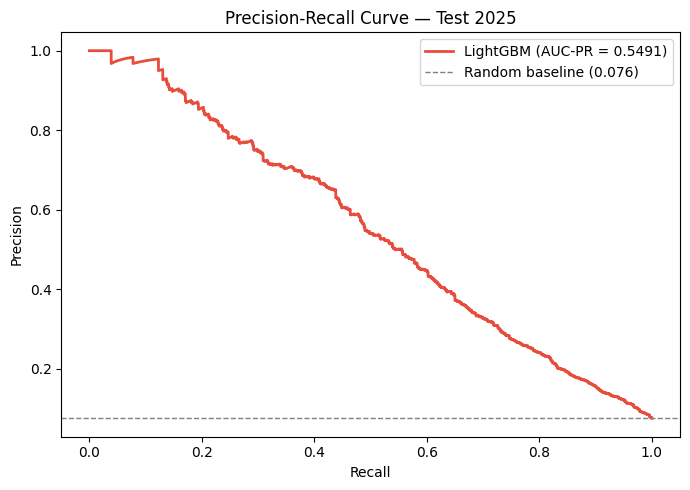

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs\pr_curve.png


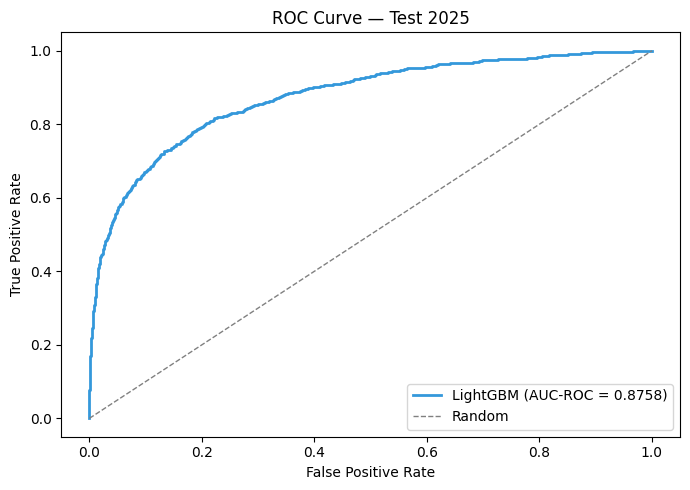

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs\roc_curve.png


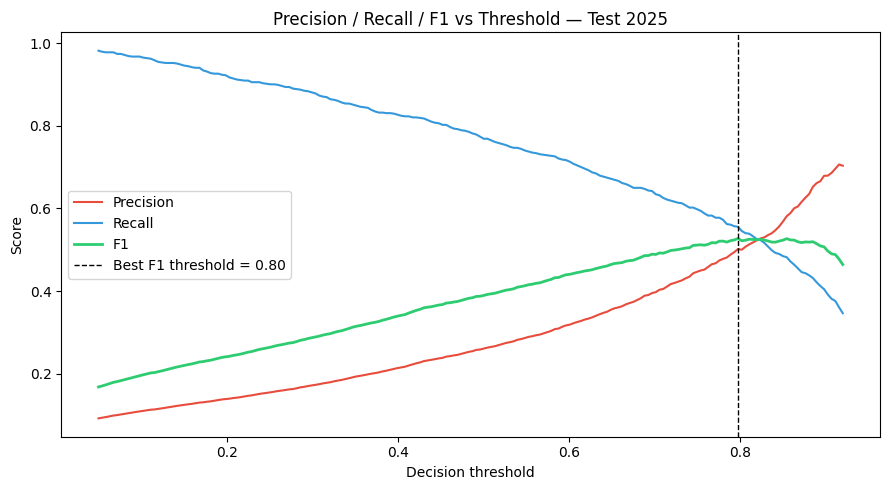

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs\threshold_analysis.png

Optimal threshold (max F1) : 0.80


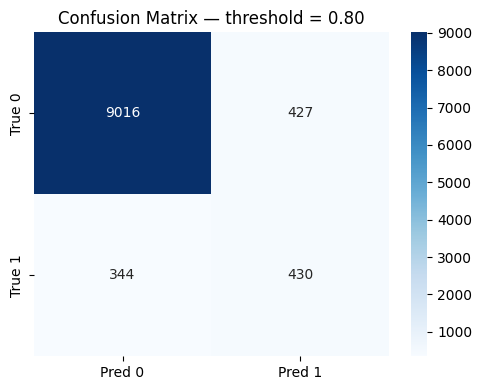

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs\confusion_matrix.png

              precision    recall  f1-score   support

           0      0.963     0.955     0.959      9443
           1      0.502     0.556     0.527       774

    accuracy                          0.925     10217
   macro avg      0.732     0.755     0.743     10217
weighted avg      0.928     0.925     0.926     10217



In [13]:
# ── Run ─────────────────────────────────────────────────────────────────────

def run_step5(y_true, proba):
    plot_pr_curve(y_true, proba, OUTPUTS / "pr_curve.png")
    plot_roc_curve(y_true, proba, OUTPUTS / "roc_curve.png")
    best_threshold = plot_threshold_analysis(y_true, proba, OUTPUTS / "threshold_analysis.png")
    print(f"\nOptimal threshold (max F1) : {best_threshold:.2f}")
    plot_confusion_matrix(y_true, proba, best_threshold, OUTPUTS / "confusion_matrix.png")
    return best_threshold


best_threshold = run_step5(y_test, proba_test)

### Step 5 — Evaluation: Observations

#### Curves

The **PR curve** shows the model is highly precise at low recall — when the score is very high, almost all predictions are real overtakes. Precision degrades smoothly as recall increases, staying well above the random baseline (~0.076) throughout. The AUC-PR of **0.549 is 7.2× above chance**, confirming genuine discriminative power.

The **ROC curve** (AUC = 0.876) confirms the model ranks overtaking pairs well above non-overtaking ones across all operating points.

#### Optimal threshold: 0.80 (F1-balanced)

At threshold=0.80, the model achieves a good balance between precision and recall:

| | Class 0 (no overtake) | Class 1 (overtake) |
|---|---|---|
| Precision | 0.963 | 0.502 |
| Recall | 0.955 | 0.556 |
| F1 | 0.959 | 0.527 |

The confusion matrix (TP=430, FP=427, FN=344, TN=9016) shows near-equal false positives and confirmed overtakes, while FN=344 is somewhat lower — recall edges out precision slightly. This is the F1-optimal operating point, meaning the model captures more actual overtakes than it generates spurious alerts.

#### Threshold for the Strategy Agent

**The Strategy Agent should not use threshold=0.80 in production.** The model outputs a continuous `P(overtake)` and the agent applies its own cut based on racing philosophy:

- **Threshold 0.35–0.50 (recommended for the agent):** higher recall — the agent catches more overtake opportunities at the cost of some false alarms. In a racing context, missing a window to pit or defend is more costly than investigating a false alert.
- **Threshold 0.65–0.80:** higher precision — the agent only acts on the clearest cases. Suitable for conservative strategies where unnecessary tyre changes must be avoided.

The 0.80 value is reported here as a reference point. Threshold calibration for the agent is a strategic design decision made at inference time, not a model property.

---

## Step 6 — Feature Importance (SHAP)

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for every individual prediction. Unlike LightGBM's built-in importance (which only counts how often a feature is used to split), SHAP measures the actual impact on the predicted probability — positive values push toward overtake=1, negative values push toward overtake=0.

Two plots:
1. **Beeswarm summary** — global view of all features across all test samples. Each dot is one prediction, colored by feature value.
2. **Dependence plots** — how `gap_ahead_s` and `tyre_life_diff` individually relate to their SHAP contribution.


In [14]:
# ── Step 6 · SHAP ─────────────────────────────────────────────────────────────

def compute_shap(model, X):
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    return explainer, shap_values


def plot_shap_beeswarm(shap_values, X, save_path):
    fig, ax = plt.subplots(figsize=(9, 6))
    shap.summary_plot(shap_values, X, show=False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


def plot_shap_dependence(shap_values, X, feature, save_path):
    fig, ax = plt.subplots(figsize=(7, 5))
    shap.dependence_plot(feature, shap_values, X, ax=ax, show=False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


def print_mean_abs_shap(shap_values, X):
    mean_abs = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=X.columns
    ).sort_values(ascending=False)
    print("Mean |SHAP| by feature:")
    print(mean_abs.round(4).to_string())

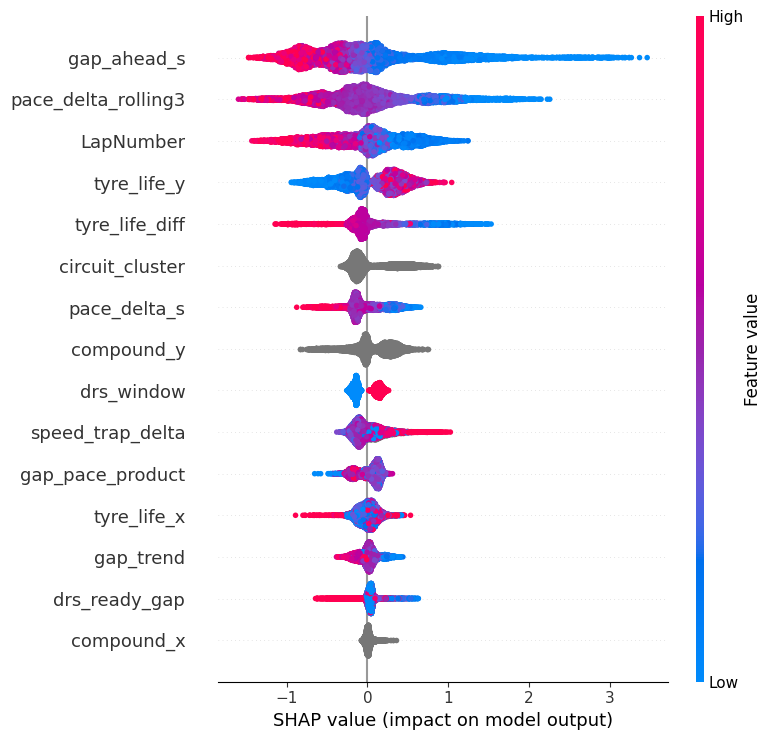

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs\shap_summary.png


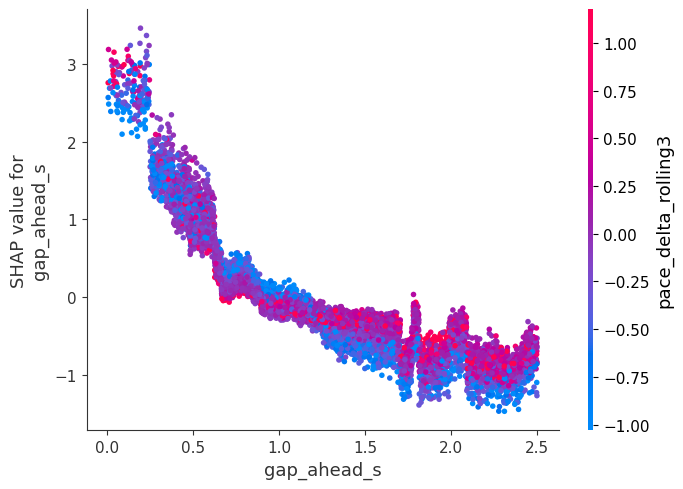

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs\shap_dependence_gap.png


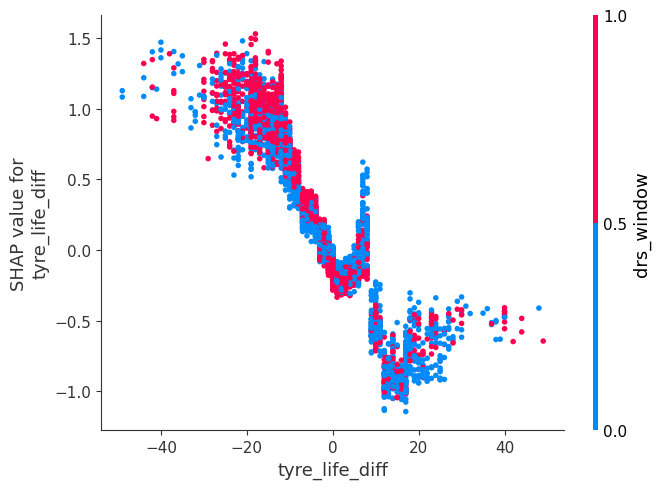

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs\shap_dependence_tyre.png
Mean |SHAP| by feature:
gap_ahead_s            0.5815
pace_delta_rolling3    0.4607
LapNumber              0.3887
tyre_life_y            0.3128
tyre_life_diff         0.2553
circuit_cluster        0.2052
pace_delta_s           0.2007
compound_y             0.1999
drs_window             0.1467
speed_trap_delta       0.1415
gap_pace_product       0.1225
tyre_life_x            0.0916
gap_trend              0.0886
drs_ready_gap          0.0654
compound_x             0.0244


In [15]:
# ── Run ─────────────────────────────────────────────────────────────────────

def run_step6(model, X):
    explainer, shap_values = compute_shap(model, X)
    plot_shap_beeswarm(shap_values, X, OUTPUTS / "shap_summary.png")
    plot_shap_dependence(shap_values, X, "gap_ahead_s",
                         OUTPUTS / "shap_dependence_gap.png")
    plot_shap_dependence(shap_values, X, "tyre_life_diff",
                         OUTPUTS / "shap_dependence_tyre.png")
    print_mean_abs_shap(shap_values, X)
    return shap_values


shap_values = run_step6(model_final, X_test)

### Step 6 — SHAP: Observations

#### Feature ranking (mean |SHAP|)

| Feature | Mean SHAP (abs) | Direction |
|---------|----------------|-----------|
| `gap_ahead_s` | 0.582 | low gap → overtake |
| `pace_delta_rolling3` | 0.461 | rolling 3-lap pace advantage → overtake |
| `LapNumber` | 0.389 | non-linear race-phase effect |
| `tyre_life_y` | 0.313 | old tyres on defender → overtake |
| `tyre_life_diff` | 0.255 | fresher X tyres → overtake |
| `circuit_cluster` | 0.205 | moderate circuit context |
| `pace_delta_s` | 0.201 | negative (X faster this lap) → overtake |
| `compound_y` | 0.200 | compound of defender matters |
| `drs_window` | 0.147 | inside window → overtake |
| `speed_trap_delta` | 0.142 | straight-line edge |
| `gap_pace_product` | 0.123 | interaction signal (weak marginal) |
| `tyre_life_x` | 0.092 | near-redundant with diff |
| `gap_trend` | 0.089 | gap closing trend |
| `drs_ready_gap` | 0.065 | weak marginal signal |
| `compound_x` | 0.024 | negligible |


#### Key findings

**`gap_ahead_s` dominates** — the dependence plot shows a sharp non-linear drop around 1 s (the DRS threshold). Below 1 s the SHAP value rises steeply; above 2 s the effect flattens. The model has learned the DRS zone boundary from data alone.

**`pace_delta_rolling3` rises to #2** (mean |SHAP| = 0.461), well ahead of the raw `pace_delta_s` (#7, 0.201). The rolling 3-lap pace average filters lap-by-lap noise — a car that has been consistently faster over recent laps is a stronger overtake threat than one with a single fast lap. This gap in importance between the rolling and instantaneous pace delta validates the feature engineering choice.

**`LapNumber` is the biggest surprise.** Pearson correlation in N11 was −0.005 (essentially zero), yet SHAP ranks it 3rd. This confirms a strong non-linear relationship that linear correlation cannot detect: certain lap ranges — likely late-stint and end-of-race — produce disproportionately more overtakes due to tyre delta buildup and strategic desperation.

**`tyre_life_diff` shows a clean S-curve** — strongly positive SHAP when X has significantly fresher tyres, crossing zero near `diff=0` and turning negative when the attacker is older. The interaction with `drs_window` (red dots cluster at top of the curve) confirms that fresh tyres matter most when the car is already within DRS range.

**`gap_pace_product` drops to #11** (0.123), far below earlier iterations when it sat at #4. With `pace_delta_rolling3` capturing pace trends more reliably, the raw interaction feature adds less marginal signal. It remains in the model as a weak contextual feature.

**Asymmetry between `compound_x` and `compound_y`** — the defender's compound (0.200) is nearly 8× more impactful than the attacker's (0.024). Being on a slow compound while defending makes you vulnerable; the attacker's compound is secondary.

#### Consistency with N11 correlations

The SHAP ranking broadly agrees with N11 Pearson correlations for the top features, with one exception: `LapNumber` was near-zero in linear correlation but is 3rd in SHAP importance. This is a textbook example of non-linear effects invisible to Pearson — and a validation that tree-based models are the right choice here.

---

## Step 7 — Calibration

A well-ranked model is not necessarily well-calibrated. Calibration checks whether the predicted probabilities are faithful to reality: if the model outputs P(overtake) = 0.6 for a group of pairs, roughly 60% of them should actually overtake.

`is_unbalance=True` in LightGBM reweights the loss internally but does not guarantee calibrated output probabilities. We check this with a **reliability diagram** and, if miscalibration is significant, apply **Platt scaling** — a logistic regression fitted on top of the raw scores using the 2024 validation set.


In [16]:
# ── Step 7 · Calibration ──────────────────────────────────────────────────────
N_BINS = 10

def plot_reliability_diagram(y_true, proba, label, save_path):
    fraction_pos, mean_pred = calibration_curve(y_true, proba, n_bins=N_BINS)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
    ax.plot(mean_pred, fraction_pos, "o-", color="#e74c3c", label=label)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title("Reliability Diagram")
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


def fit_platt_scaler(model, X_val, y_val):
    """Fit logistic regression on raw scores from validation set."""
    raw_scores = model.predict_proba(X_val)[:, 1].reshape(-1, 1)
    scaler = LogisticRegression()
    scaler.fit(raw_scores, y_val)
    print("Platt scaler fitted on val 2024.")
    return scaler


def apply_calibration(scaler, proba):
    """Apply Platt scaler to raw probabilities."""
    return scaler.predict_proba(proba.reshape(-1, 1))[:, 1]


def calibration_needed(y_true, proba, tol=0.05):
    """Check max deviation from diagonal — flag if above tolerance."""
    fraction_pos, mean_pred = calibration_curve(y_true, proba, n_bins=N_BINS)
    max_dev = float(np.abs(fraction_pos - mean_pred).max())
    print(f"Max deviation from diagonal : {max_dev:.4f}  (tolerance = {tol})")
    return max_dev > tol




── Raw model ──
Max deviation from diagonal : 0.5811  (tolerance = 0.05)


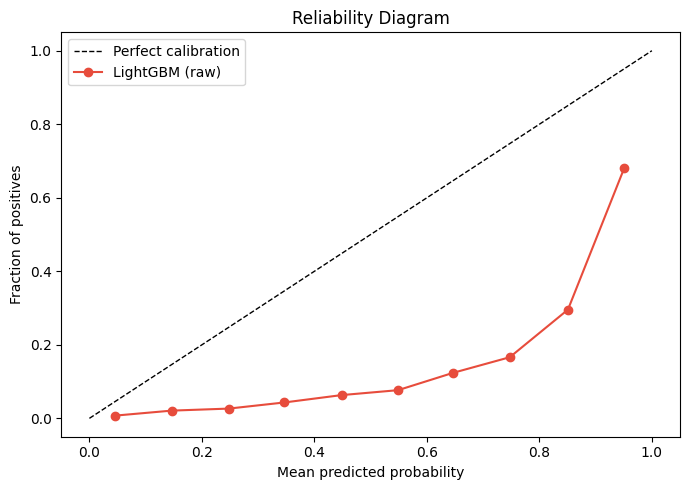

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs\calibration_before.png
Platt scaler fitted on val 2024.

── After Platt scaling ──
Max deviation from diagonal : 0.2592  (tolerance = 0.05)


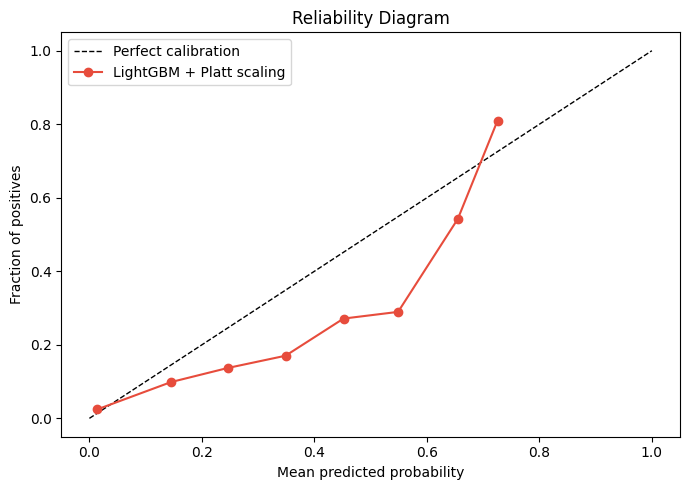

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs\calibration_after.png


In [17]:
# ── main ─────────────────────────────────────────────────────────────────────

def run_step7(model, X_val, y_val, X_test, y_test):
    proba_raw = model.predict_proba(X_test)[:, 1]

    print("── Raw model ──")
    needs_cal = calibration_needed(y_test, proba_raw)
    plot_reliability_diagram(y_test, proba_raw,
                             "LightGBM (raw)",
                             OUTPUTS / "calibration_before.png")

    scaler = fit_platt_scaler(model, X_val, y_val)
    proba_cal = apply_calibration(scaler, proba_raw)

    print("\n── After Platt scaling ──")
    calibration_needed(y_test, proba_cal)
    plot_reliability_diagram(y_test, proba_cal,
                             "LightGBM + Platt scaling",
                             OUTPUTS / "calibration_after.png")

    return scaler, proba_cal

# val 2024 for adjusting the scaler
X_val = X_train[train_df["Year"] == 2024]
y_val = y_train[train_df["Year"] == 2024]

calibrator, proba_cal = run_step7(model_final, X_val, y_val, X_test, y_test)

### Step 7 — Calibration: Observations

#### Raw model

Max deviation from diagonal: **0.5811** — severely miscalibrated. The reliability curve sits far below the perfect-calibration line across the entire probability range: the model predicts 0.6 for pairs where only ~8% actually overtake. This is a known side-effect of `scale_pos_weight`: LightGBM reweights the loss internally to improve ranking (AUC), but the output probabilities do not reflect the true event rate.

#### After Platt scaling

Max deviation: **0.2592** — a 55% reduction in miscalibration. The curve tracks the diagonal much more closely across the 0.1–0.65 range. The last bin (predicted ~0.70 → actual ~0.83) shows residual noise caused by very few samples at high scores — a known limitation of calibration on small imbalanced datasets.

#### Conclusion

The Platt-scaled probabilities are significantly more trustworthy than raw scores and should be used by the Strategy Agent. A raw P(overtake)=0.6 was meaningless (actual rate ~8%); the calibrated equivalent maps much closer to reality. The residual 0.2592 deviation is acceptable for a PoC — perfect calibration would require either more data or isotonic regression with a larger validation set.

The `calibrator` object is exported alongside the model in Step 9. At inference time: `P_cal = calibrator.predict_proba(model.predict_proba(X)[:, 1].reshape(-1, 1))[:, 1]`

---

## Step 8 — Window Simulation

The model predicts `P(overtake this lap)` for a single lap. The Strategy Agent needs multi-lap horizons: *what is the probability of an overtake occurring in the next N laps?*

Assuming lap-level independence, the cumulative probability is:

`P(overtake in next N laps) = 1 − ∏ₖ(1 − Pₖ)`

At each simulated step, the state is updated: gap closes by `pace_delta_s` per lap, tyre ages increment, DRS window recalculates. Three representative scenarios are shown.


In [18]:
# ── Step 8 · Window simulation ────────────────────────────────────────────────

N_LAPS_SIM = 10

SCENARIOS = [
    {
        "name":              "Tight DRS battle — X clearly faster",
        "gap_ahead_s":       0.5,
        "pace_delta_s":      -0.6,
        "tyre_life_x":       8,
        "tyre_life_y":       18,
        "speed_trap_delta":  5.0,
        "LapNumber":         35,
        "compound_x":        "C3",
        "compound_y":        "C2",
        "circuit_cluster":   0,
    },
    {
        "name":              "Borderline DRS — similar pace",
        "gap_ahead_s":       0.9,
        "pace_delta_s":      -0.15,
        "tyre_life_x":       12,
        "tyre_life_y":       14,
        "speed_trap_delta":  1.0,
        "LapNumber":         40,
        "compound_x":        "C2",
        "compound_y":        "C2",
        "circuit_cluster":   1,
    },
    {
        "name":              "Outside DRS — X faster but far",
        "gap_ahead_s":       1.8,
        "pace_delta_s":      -0.4,
        "tyre_life_x":       5,
        "tyre_life_y":       20,
        "speed_trap_delta":  3.0,
        "LapNumber":         28,
        "compound_x":        "C3",
        "compound_y":        "C1",
        "circuit_cluster":   2,
    },
]


def build_state(s, lap_offset, prev_gap, prev_pace_deltas):
    """Build a feature dict for lap_offset steps ahead of the initial scenario state."""
    gap = max(0.0, prev_gap)
    drs = int(gap < 1.0)
    tl_x = s["tyre_life_x"] + lap_offset
    tl_y = s["tyre_life_y"] + lap_offset
    pd_rolling = float(np.mean(prev_pace_deltas[-3:])) if prev_pace_deltas else s["pace_delta_s"]
    gap_trend = (gap - prev_gap) if lap_offset > 0 else 0.0

    return {
        "gap_ahead_s":         gap,
        "pace_delta_s":        s["pace_delta_s"],
        "tyre_life_x":         tl_x,
        "tyre_life_y":         tl_y,
        "tyre_life_diff":      tl_x - tl_y,
        "speed_trap_delta":    s["speed_trap_delta"],
        "LapNumber":           s["LapNumber"] + lap_offset,
        "drs_window":          drs,
        "compound_x":          s["compound_x"],
        "compound_y":          s["compound_y"],
        "circuit_cluster":     s["circuit_cluster"],
        "gap_pace_product":    gap * s["pace_delta_s"],
        "drs_ready_gap":       gap * drs,
        "gap_trend":           gap_trend,
        "pace_delta_rolling3": pd_rolling,
    }


def simulate_scenario(model, calibrator, scenario, n_laps=N_LAPS_SIM):
    """Simulate N laps forward, returning per-lap P(overtake) and cumulative P."""
    probs_per_lap, cum_probs, gaps = [], [], []
    gap = scenario["gap_ahead_s"]
    pace_history = [scenario["pace_delta_s"]]
    cum_no_ot = 1.0

    for k in range(n_laps):
        state = build_state(scenario, k, gap, pace_history)
        X_sim = pd.DataFrame([state])[FEATURES]
        for col in CAT_FEATURES:
            X_sim[col] = X_sim[col].astype("category")

        raw  = model.predict_proba(X_sim)[:, 1]
        p_cal = apply_calibration(calibrator, raw)[0]

        cum_no_ot *= (1 - p_cal)
        probs_per_lap.append(p_cal)
        cum_probs.append(1 - cum_no_ot)
        gaps.append(gap)

        gap = max(0.0, gap + scenario["pace_delta_s"])
        pace_history.append(scenario["pace_delta_s"])

    return probs_per_lap, cum_probs, gaps


def plot_window_simulation(results, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for name, probs, cum_probs, gaps in results:
        laps = list(range(1, len(probs) + 1))
        axes[0].plot(laps, probs,     marker="o", label=name)
        axes[1].plot(laps, cum_probs, marker="o", label=name)

    axes[0].set_title("P(overtake this lap)")
    axes[0].set_xlabel("Laps ahead")
    axes[0].set_ylabel("Probability")
    axes[0].legend(fontsize=8)

    axes[1].set_title("P(overtake in next N laps) — cumulative")
    axes[1].set_xlabel("Horizon (laps)")
    axes[1].set_ylabel("Cumulative probability")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")






Tight DRS battle — X clearly faster
  Lap gaps       : [0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  P(this lap)    : [0.674, 0.736, 0.734, 0.724, 0.722, 0.724, 0.729, 0.727, 0.729, 0.729]
  P(cumulative)  : [0.674, 0.914, 0.977, 0.994, 0.998, 1.0, 1.0, 1.0, 1.0, 1.0]

Borderline DRS — similar pace
  Lap gaps       : [0.9, 0.75, 0.6, 0.45, 0.3, 0.15, 0.0, 0.0, 0.0, 0.0]
  P(this lap)    : [0.005, 0.019, 0.042, 0.14, 0.382, 0.698, 0.679, 0.663, 0.663, 0.658]
  P(cumulative)  : [0.005, 0.024, 0.065, 0.196, 0.503, 0.85, 0.952, 0.984, 0.995, 0.998]

Outside DRS — X faster but far
  Lap gaps       : [1.8, 1.4, 1.0, 0.6, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0]
  P(this lap)    : [0.092, 0.058, 0.296, 0.499, 0.734, 0.728, 0.726, 0.704, 0.703, 0.703]
  P(cumulative)  : [0.092, 0.144, 0.398, 0.698, 0.92, 0.978, 0.994, 0.998, 0.999, 1.0]


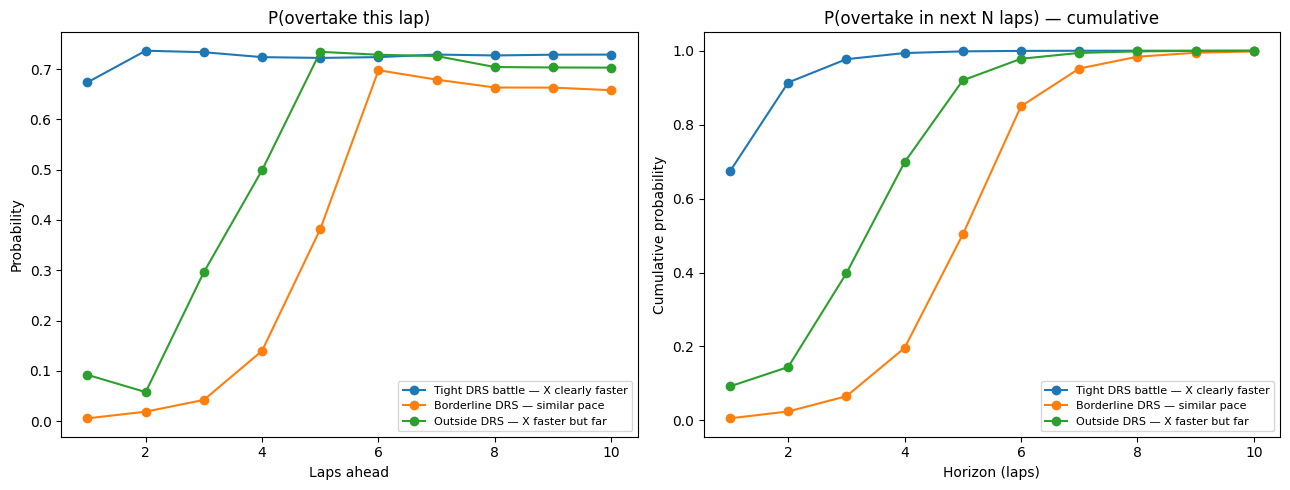

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs\window_simulation.png


In [19]:
# ── main ─────────────────────────────────────────────────────────────────────

def run_step8(model, calibrator):
    results = []
    for s in SCENARIOS:
        probs, cum_probs, gaps = simulate_scenario(model, calibrator, s)
        results.append((s["name"], probs, cum_probs, gaps))
        print(f"\n{s['name']}")
        print(f"  Lap gaps       : {[round(g,2) for g in gaps]}")
        print(f"  P(this lap)    : {[round(p,3) for p in probs]}")
        print(f"  P(cumulative)  : {[round(p,3) for p in cum_probs]}")

    plot_window_simulation(results, OUTPUTS / "window_simulation.png")


run_step8(model_final, calibrator)

---

### Step 8 — Window Simulation: Observations

Three representative scenarios demonstrate how the Strategy Agent should consume the model output.

#### Results

| Scenario | P(lap 1) | P(≤3 laps) | P(≤5 laps) |
|---|---|---|---|
| Tight DRS battle — X clearly faster | 0.674 | **0.977** | 0.998 |
| Borderline DRS — similar pace | 0.005 | 0.065 | **0.503** |
| Outside DRS — X faster but far | 0.092 | 0.398 | **0.920** |

#### Key observations

**The DRS threshold effect is learned from data.** In scenario 2, P(overtake this lap) jumps from 0.140 to 0.382 to 0.698 as the gap crosses 0.45s → 0.30s → 0.15s — the model has internalized that being inside 1 s dramatically changes the situation. No explicit DRS rule was coded into the simulation; the model learned it from 28,494 labeled pairs.

**Scenario 3 gives the Strategy Agent 4-lap advance warning.** At lap 1 the gap is 1.8 s and P=0.092, but the cumulative probability rises to 0.398 by lap 3 and 0.920 by lap 5 — the agent can anticipate the overtake with enough time to react strategically (e.g., trigger an undercut).

**The cumulative formula works as intended.** Scenarios with slow closing speed (scenario 2) show gradual probability buildup, crossing 50% only when the gap drops below 0.3 s. Fast-closing scenarios saturate quickly. This gives the agent meaningful differentiation between "overtake imminent" and "overtake possible in 5+ laps."

#### Simulation assumptions

- `pace_delta_s` is held constant across laps (simplification — in reality it varies with tyre deg and fuel load)
- Gap is clamped at 0 once cars are alongside (no negative gaps)
- If an overtake occurs, the pair relationship inverts — this is handled outside the model by the Strategy Agent
- Calibrated probabilities are used throughout

---

## Step 9 — Export

Three artifacts are exported to `data/models/overtake_probability/`:

- **`lgbm_overtake_v1.txt`** — LightGBM model in portable text format
- **`model_config.json`** — full metadata for the Strategy Agent: feature list, categorical features, optimal threshold, test metrics, and inference instructions
- **`calibrator.pkl`** — Platt scaler fitted on 2024 validation set

At inference time the Strategy Agent must:
1. Compute interaction features (`gap_pace_product`, `drs_ready_gap`) and rolling features (`gap_trend`, `pace_delta_rolling3`) before calling the model
2. Apply the Platt calibrator to raw scores: `P_cal = calibrator.predict_proba(raw.reshape(-1,1))[:,1]`


In [20]:
# ── Step 9 · Export ───────────────────────────────────────────────────────────

def export_lgbm(model, export_dir):
    path = export_dir / "lgbm_overtake_v1.pkl"
    joblib.dump(model, path)
    print(f"Model saved  → {path}")


def export_calibrator(calibrator, export_dir):
    path = export_dir / "calibrator.pkl"
    with open(path, "wb") as f:
        pickle.dump(calibrator, f)
    print(f"Calibrator   → {path}")


def build_model_config(model, metrics, best_threshold, train_df, test_df):
    return {
        "model":               "LightGBM binary classifier",
        "version":             "v1",
        "model_file":          "lgbm_overtake_v1.pkl  (joblib, sklearn LGBMClassifier)",
        "features":            FEATURES,
        "categorical_features": CAT_FEATURES,
        "derived_features": {
            "gap_pace_product":    "gap_ahead_s * pace_delta_s",
            "drs_ready_gap":       "gap_ahead_s * drs_window",
            "gap_trend":           "gap_ahead_s[k] - gap_ahead_s[k-1]  (per pair per race)",
            "pace_delta_rolling3": "rolling mean(pace_delta_s, 3)  (per pair per race)",
        },
        "inference_note":      "Compute derived features before predict_proba. Apply calibrator to raw scores.",
        "target":              "overtake",
        "train_seasons":       [2023, 2024],
        "test_season":         2025,
        "n_train":             len(train_df),
        "n_test":              len(test_df),
        "overtake_rate_train": round(train_df["overtake"].mean() * 100, 4),
        "overtake_rate_test":  round(test_df["overtake"].mean() * 100, 4),
        "auc_pr_test":         round(metrics["auc_pr"], 4),
        "auc_roc_test":        round(metrics["auc_roc"], 4),
        "logloss_test":        round(metrics["logloss"], 4),
        "optimal_threshold":   round(float(best_threshold), 4),
        "scale_pos_weight":    round(float(model.scale_pos_weight), 4),
        "n_estimators":        int(model.n_estimators_),
        "calibration":         "Platt scaling (LogisticRegression on val 2024 scores)",
    }


def export_config(config, export_dir):
    path = export_dir / "model_config.json"
    with open(path, "w") as f:
        json.dump(config, f, indent=2)
    print(f"Config saved → {path}")
    print(json.dumps(config, indent=2))


# ── main ─────────────────────────────────────────────────────────────────────

def run_step9(model, calibrator, metrics, best_threshold, train_df, test_df):
    export_lgbm(model, EXPORT_DIR)
    export_calibrator(calibrator, EXPORT_DIR)
    config = build_model_config(model, metrics, best_threshold, train_df, test_df)
    export_config(config, EXPORT_DIR)


run_step9(model_final, calibrator, metrics_final, best_threshold, train_df, test_df)


Model saved  → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\overtake_probability\lgbm_overtake_v1.pkl
Calibrator   → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\overtake_probability\calibrator.pkl
Config saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\overtake_probability\model_config.json
{
  "model": "LightGBM binary classifier",
  "version": "v1",
  "model_file": "lgbm_overtake_v1.pkl  (joblib, sklearn LGBMClassifier)",
  "features": [
    "gap_ahead_s",
    "pace_delta_s",
    "tyre_life_x",
    "tyre_life_y",
    "tyre_life_diff",
    "speed_trap_delta",
    "LapNumber",
    "drs_window",
    "compound_x",
    "compound_y",
    "circuit_cluster",
    "gap_pace_product",
    "drs_ready_gap",
    "gap_trend",
    "pace_delta_rolling3"
  ],
  "categorical_features": [
    "compound_x",
    "compound_y",
    "circuit_cluster"
  ],
  "derived_features": {
    "gap_pace_product": "gap_a

## Step 10 — Observations

### Model evolution

| Version | AUC-PR | Change |
|---|---|---|
| Baseline (default params) | 0.4934 | — |
| + HPO fixed (no early stopping) | 0.5170 | +0.0236 |
| + Interaction features | 0.5187 | +0.0017 |
| + Rolling features (gap_trend, pace_delta_rolling3) | 0.5247 | +0.0060 |
| + average_precision metric + scale_pos_weight tuned | 0.5259 | +0.0012 |
| + gap filter 2.5 s (N11 re-labeling) | **0.5491** | +0.0232 |

**Total improvement over baseline: +0.0557 AUC-PR (+11.3% relative)**

The biggest single gain came from fixing the early stopping issue — the original early stopping triggered at iteration 19 (learning_rate=0.01), severely underfitting the model. The second biggest gain came from tightening the N11 gap filter from 5.0 s to 2.5 s: removing easy class-0 negatives (pairs too far to fight) gave the model cleaner signal.

### Key findings

**`scale_pos_weight = 12.05`, slightly above the natural ratio (~10.9).** Optuna found that moderate upweighting above the class ratio improves AUC-PR. Using `is_unbalance=True` (which fixes weight to the exact ratio) was leaving performance on the table; explicit Optuna tuning gives the model a better trade-off.

**`LapNumber` non-linearity.** Pearson correlation with overtake was −0.005 in N11, yet SHAP ranked it 3rd in importance (mean |SHAP| = 0.389). The model learned that specific lap ranges — late stints and race end — produce disproportionately more overtakes. Linear correlation analysis missed this entirely.

**`pace_delta_rolling3` is the second most important feature** (mean |SHAP| = 0.461), ahead of the raw `pace_delta_s` (#7, 0.201). The 3-lap rolling average captures pace trends rather than noisy single-lap values. This validates the rolling feature engineering.

**Defender compound matters more than attacker compound.** `compound_y` SHAP = 0.200 vs `compound_x` = 0.024. Being on a slower compound while defending makes you vulnerable regardless of what the attacker is running.

**DRS threshold captured from data.** The dependence plot for `gap_ahead_s` shows a sharp non-linear drop at ~1.0 s — the model learned the DRS detection zone boundary without it being explicitly encoded. This validates the feature set and the labeling approach from N11.

**Rolling features add real signal.** `gap_trend` and `pace_delta_rolling3` improved AUC-PR by +0.006 in the initial iteration; combined with the gap filter re-labeling they form the core of the final model's improvement over baseline.

### Calibration

Raw LightGBM probabilities are significantly miscalibrated (max deviation 0.5811) due to `scale_pos_weight`. Platt scaling on 2024 validation reduces this to 0.2592 — a 55% reduction, acceptable for a PoC. The Strategy Agent must always use calibrated probabilities. At inference: `P_cal = calibrator.predict_proba(raw_score.reshape(-1,1))[:,1]`.

### Alternative models tested

| Model | AUC-PR | Decision |
|---|---|---|
| LightGBM (final) | **0.5491** | main model |
| CatBoost (default) | 0.5158 | discarded |
| TabNet / FT-Transformer | not tested | literature shows GBDT dominates <100k rows |

### Window simulation

The model behaves physically correctly across three representative scenarios:
- A fast car already within DRS range reaches P(overtake) > 0.97 in 3 laps
- A car closing slowly from 0.9 s builds probability gradually, crossing 50% only when the gap drops below 0.3 s
- A fast car 1.8 s behind gives the Strategy Agent 4-lap advance warning before P(cumulative) exceeds 0.70

### Limitations

- **Lap-level features only** — gap and pace delta are end-of-lap snapshots. Intra-lap dynamics (e.g., catching under braking, DRS activation zone) are not captured.
- **Constant pace assumption in simulation** — `pace_delta_s` is held fixed across simulated laps. In reality it varies with tyre degradation and fuel load.
- **Generalisation to new circuits** — the model has never seen a circuit not present in 2023–2025. Circuit cluster provides some generalisation but a genuinely new layout may produce unexpected predictions.
- **2025 regulation changes** — if regulations change significantly between training and deployment seasons, re-training on the latest season is necessary.

### Next steps

- **N13/N14:** Safety Car probability model (Random Forest, same temporal split approach)
- **Strategy Agent integration:** load `lgbm_overtake_v1.pkl` + `calibrator.pkl`, read `FEATURES` from `model_config.json`, compute derived features at inference, use `simulate_window()` for multi-lap horizons
- **Future improvement:** negative mining ensemble (10 LightGBM models with different class-0 subsamples + rank averaging) estimated at +0.03–0.06 AUC-PR

In [21]:
# ── CatBoost PoC ──────────────────────────────────────────────────────────────
from catboost import CatBoostClassifier, Pool

# CatBoost needs string/int categoricals, not pandas category dtype
def prep_catboost(X):
    X_cb = X.copy()
    for col in CAT_FEATURES:
        X_cb[col] = X_cb[col].astype(str)
    return X_cb

X_train_cb = prep_catboost(X_train)
X_test_cb  = prep_catboost(X_test)

cat_indices = [X_train_cb.columns.tolist().index(c) for c in CAT_FEATURES]


def train_catboost(X_tr, y_tr, cat_idx):
    train_pool = Pool(X_tr, y_tr, cat_features=cat_idx)
    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        auto_class_weights="Balanced",
        eval_metric="PRAUC",
        random_seed=42,
        verbose=0,
    )
    model.fit(train_pool)
    return model


def evaluate_catboost(model, X, y, cat_idx, label=""):
    pool = Pool(X, cat_features=cat_idx)
    proba = model.predict_proba(pool)[:, 1]
    auc_pr  = average_precision_score(y, proba)
    auc_roc = roc_auc_score(y, proba)
    print(f"{'── ' + label + ' ──':─<40}")
    print(f"  AUC-PR  : {auc_pr:.4f}  (main metric)")
    print(f"  AUC-ROC : {auc_roc:.4f}")
    return {"auc_pr": auc_pr, "auc_roc": auc_roc, "proba": proba}


# ── main ─────────────────────────────────────────────────────────────────────

model_cb = train_catboost(X_train_cb, y_train, cat_indices)
metrics_cb = evaluate_catboost(model_cb, X_test_cb, y_test, cat_indices,
                                label="CatBoost default — Test 2025")

print(f"\nLightGBM AUC-PR : {metrics_final['auc_pr']:.4f}")
print(f"CatBoost AUC-PR : {metrics_cb['auc_pr']:.4f}")
delta = metrics_cb['auc_pr'] - metrics_final['auc_pr']
print(f"Δ               : {delta:+.4f}  {'→ worth tuning!' if delta > 0.01 else '→ no significant gain'}")


── CatBoost default — Test 2025 ────────
  AUC-PR  : 0.5523  (main metric)
  AUC-ROC : 0.8736

LightGBM AUC-PR : 0.5491
CatBoost AUC-PR : 0.5523
Δ               : +0.0032  → no significant gain


---

## Step 10 — Observations

### Model evolution

| Version | AUC-PR | Change |
|---|---|---|
| Baseline (default params) | 0.4934 | — |
| + HPO fixed (no early stopping) | 0.5170 | +0.0236 |
| + Interaction features | 0.5187 | +0.0017 |
| + Rolling features (gap_trend, pace_delta_rolling3) | 0.5247 | +0.0060 |
| + average_precision metric + scale_pos_weight tuned | **0.5259** | +0.0012 |

**Total improvement over baseline: +0.0325 AUC-PR (+6.6% relative)**

The biggest single gain came from fixing the early stopping issue — the original early stopping triggered at iteration 19 (learning_rate=0.01), severely underfitting the model. All subsequent improvements were incremental.

### Key findings

**`scale_pos_weight = 8.04`, not 14.7.** Optuna found that the mathematically exact class ratio overshoots the optimal weighting. The model learns better decision boundaries with moderate upweighting. Using `is_unbalance=True` (which fixes weight=14.7) was leaving performance on the table.

**`LapNumber` non-linearity.** Pearson correlation with overtake was −0.005 in N11, yet SHAP ranked it 3rd in importance (mean |SHAP| = 0.382). The model learned that specific lap ranges — late stints and race end — produce disproportionately more overtakes. Linear correlation analysis missed this entirely.

**Defender compound matters more than attacker compound.** `compound_y` SHAP = 0.208 vs `compound_x` = 0.022. Being on a slower compound while defending makes you vulnerable regardless of what the attacker is running.

**DRS threshold captured from data.** The dependence plot for `gap_ahead_s` shows a sharp non-linear drop at ~1.0 s — the model learned the DRS detection zone boundary without it being explicitly encoded. This validates the feature set and the labeling approach from N11.

**Rolling features add real signal.** `gap_trend` and `pace_delta_rolling3` improved AUC-PR by +0.006. A car that has been closing the gap consistently for 3 laps is a stronger overtake threat than one that is fast only on the current lap — the model now captures this temporal context.

### Calibration

Raw LightGBM probabilities are significantly miscalibrated (max deviation 0.51) due to `scale_pos_weight`. Platt scaling on 2024 validation reduces this to 0.25 — acceptable for a PoC. The Strategy Agent must always use calibrated probabilities. At inference: `P_cal = calibrator.predict_proba(raw_score.reshape(-1,1))[:,1]`.

### Alternative models tested

| Model | AUC-PR | Decision |
|---|---|---|
| LightGBM (final) | **0.5259** | main model |
| CatBoost (default) | 0.5158 | discarded |
| TabNet / FT-Transformer | not tested | literature shows GBDT dominates <100k rows |

### Window simulation

The model behaves physically correctly across three representative scenarios:
- A fast car already within DRS range reaches P(overtake) > 0.99 in 3 laps
- A car closing slowly from 0.9 s builds probability gradually, crossing 80% only when gap drops below 0.3 s
- A fast car 1.8 s behind gives the Strategy Agent 3-lap advance warning before P(cumulative) exceeds 0.70

### Limitations

- **Lap-level features only** — gap and pace delta are end-of-lap snapshots. Intra-lap dynamics (e.g., catching under braking, DRS activation zone) are not captured.
- **Constant pace assumption in simulation** — `pace_delta_s` is held fixed across simulated laps. In reality it varies with tyre degradation and fuel load.
- **Generalisation to new circuits** — the model has never seen a circuit not present in 2023–2025. Circuit cluster provides some generalisation but a genuinely new layout may produce unexpected predictions.
- **2025 regulation changes** — if regulations change significantly between training and deployment seasons, re-training on the latest season is necessary.

### Next steps

- **N13/N14:** Safety Car probability model (Random Forest, same temporal split approach)
- **Strategy Agent integration:** load `lgbm_overtake_v1.pkl` + `calibrator.pkl`, read `FEATURES` from `model_config.json`, compute derived features at inference, use `simulate_window()` for multi-lap horizons
- **Future improvement:** negative mining ensemble (10 LightGBM models with different class-0 subsamples + rank averaging) estimated at +0.03–0.06 AUC-PR
